# TRIQS/ModEST

By this point in the TRIQS tutorials, you have developed a working understanding of Dynamical Mean-Field Theory (DMFT), a powerful approach for treating strong local electronic correlations in lattice systems. You’ve seen how DMFT captures the dynamical nature of electron-electron interactions, going beyond static mean-field methods and providing a more accurate description of correlated electrons.

By now, you have applied DMFT to model Hamiltonians. In order to use DMFT for the study of a realistic system, we want to connect DMFT to a first-principles method that can supply the appropriate non-interacting starting point and interactions. One typical method of choice is density functional theory (DFT), which provides an electronic structure based on the atomic composition of a material. The TRIQS/**M**odular **E**lectronic **S**tructure **T**oolkit (TRIQS/ModEST) provides the tools to make this connection.

**This notebook** serves as the home base for the ModEST tutorials. We quickly review the key concepts of DFT+DMFT, introduce the two key concepts required to connect DFT to DMFT: the one-body elements (obe) and the embedding, and present the sequence of tutorials in which you will learn how to use TRIQS/ModEST to build DMFT-type calculations in the context of real materials.

## DFT + DMFT

Quantum embedding methods like DFT+DMFT provide a powerful framework to describe strongly correlated materials by combining the strengths of density functional theory (DFT) with a many-body technique such as DMFT. While DFT provides an efficient, parameter-free framework for calculating the ground-state properties of materials based on their chemical composition, it only works well for weakly correlated systems and often fails in the presence of strong local interactions, for example, those found in transition metal oxides, heavy fermion compounds, or actinides. DFT tends to delocalize electrons that, in reality, exhibit localized and strongly correlated behavior. On the other hand, DMFT is excellent at capturing strong local correlations; however, it can only handle the correlations of a smaller set of degrees of freedom due to the computational cost of solving impurity problems.

The interface goes as follows:
1. Start from a complete description of a system given by an **electronic dispersion** $\epsilon(\textbf{k})$ obtained using DFT. This object encapsulates the material-specific information about the crystal structure, atomic species, and chemical bonding. It serves as a backbone for the full many-body problem.
2. Identify a set of localized orbitals where the interactions are better defined. They are expressed as a linear combination of the DFT Bloch basis, yielding a set of **projectors**.
3. Map these degrees of freedom to a set of effective systems called impurity problems. These mappings define the set of **embeddings**. The local correlations are obtained by **solving** the impurity problems.
4. **Embed back** the many-body solutions onto the whole lattice by expressing them in the original Bloch basis.

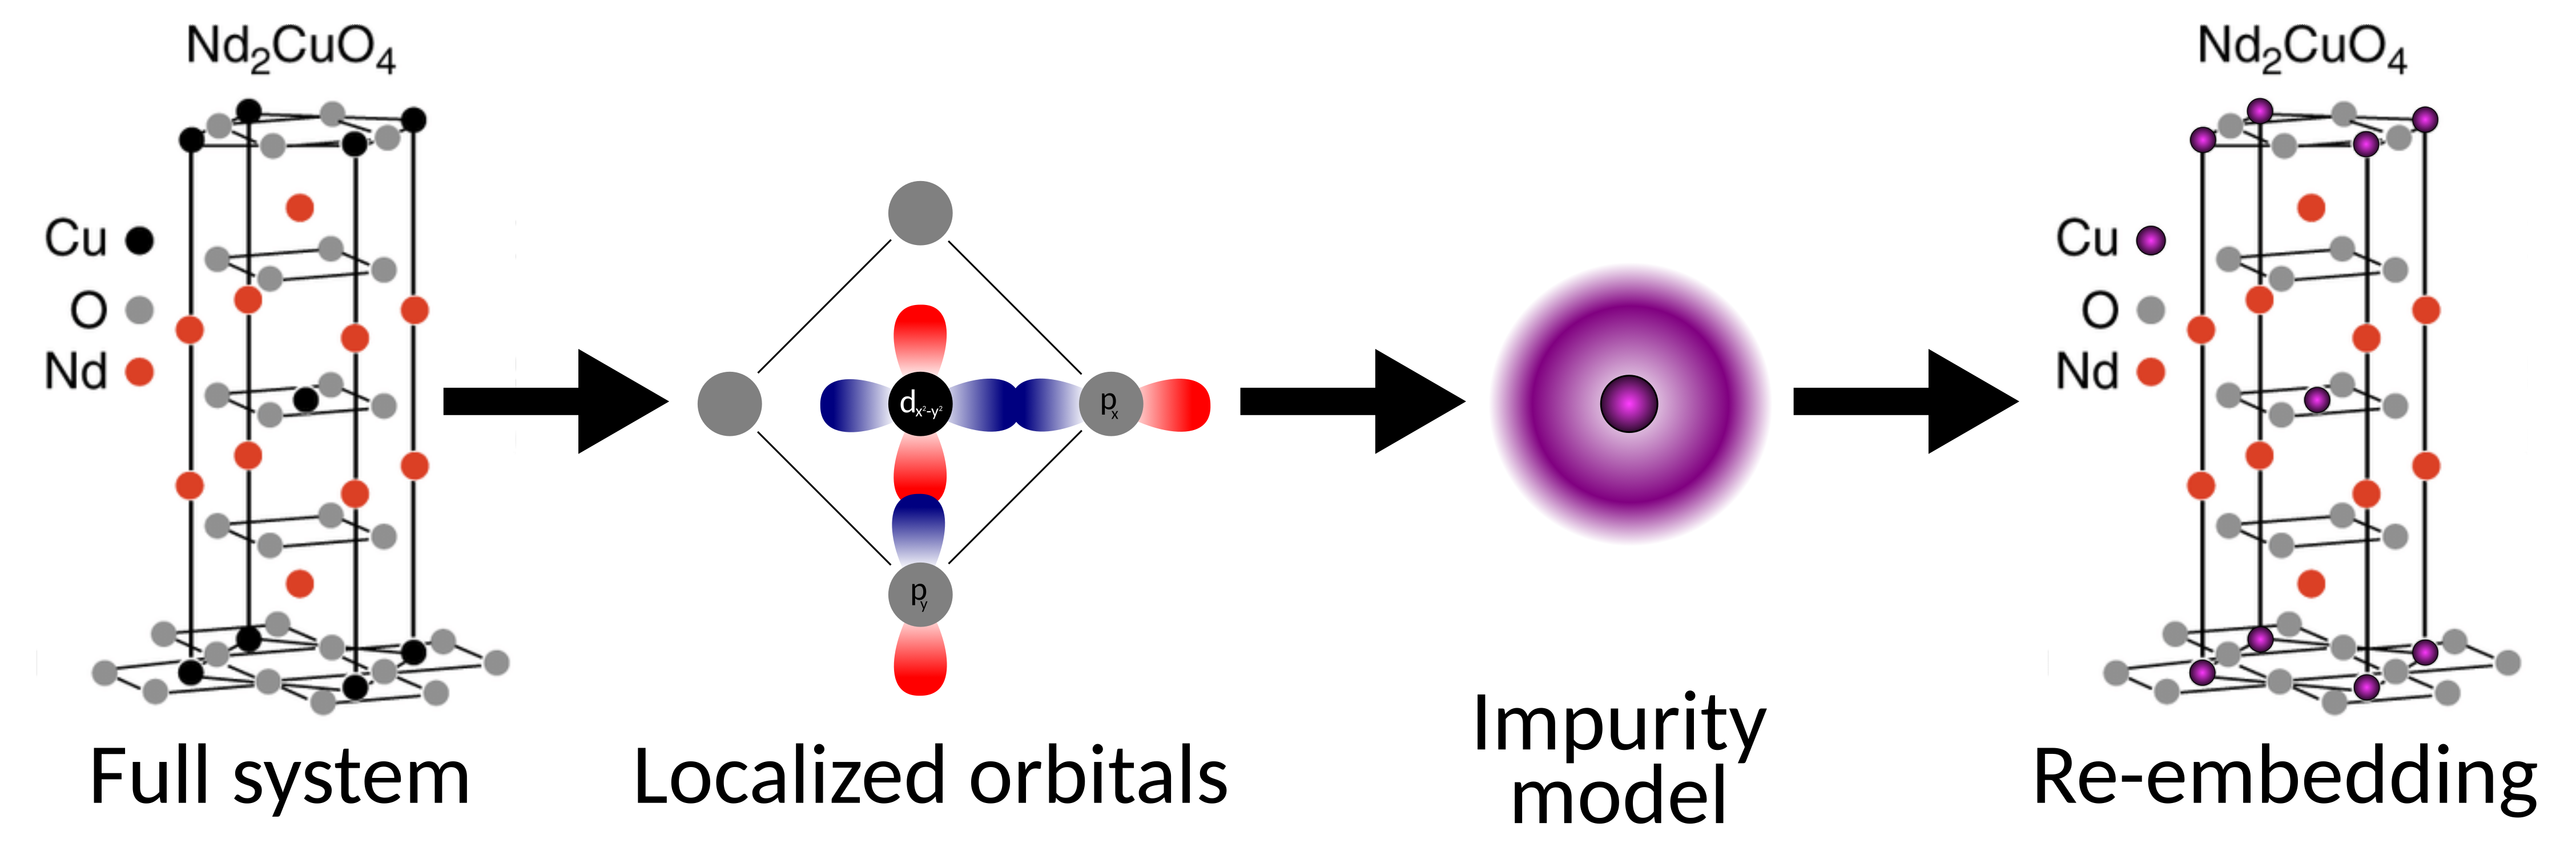

## Abstraction of TRIQS/ModEST

TRIQS/ModEST has two key abstractions that are used quite frequently in all of the tutorials. These pieces are essential to build modular DMFT loops with a number of different self-consistency conditions. The two key abstractions are:


### 1. One-body elements (obe for short)

The **obe** contains all of the one-body information that surrounds the DMFT calculation, like the DFT data and the set of local orbitals.

### 2. Embedding

The embedding class describes the **mapping between the local correlated space $\mathcal{C}$ and the set of impurity problems $\mathcal{I}$**. The choice of embedding determines the type of many-body physics that will be captured and re-embedded to the lattice.

You will learn how to use these pieces by completing the tutorials. For more details on the implementation and API, please see the TRIQS/ModEST documentation.

# Tutorials

In this sequence of tutorials, we will learn how to use **TRIQS/ModEST** to build electronic structure calculations of real strongly correlated materials using the union of *ab initio* methods such as density functional theory (DFT) or many-body perturbation theory (e.g., GW), with a many-body method like DMFT.

Our tutorials will focus mostly on La$_{2}$CuO$_{4}$, one of the parent compounds in the family of cuprate high-temperature superconductors. Although conventional DFT predicts a metallic solution, in reality it is a canonical example of a strongly correlated quantum material that exhibits rich physics, including a Mott insulating state, antiferromagnetism, and, upon doping, unconventional superconductivity. Despite its layered structure, the essential low-energy physics of La$_{2}$CuO$_{4}$ arises predominantly from the CuO$_{2}$ planes, where the Cu-$3d_{x^{2}-y^{2}}$ orbitals hybridize with the oxygen $2p$ states to form a narrow antibonding band near the Fermi level.

To capture these phenomena, La$_{2}$CuO$_{4}$ is often modeled by an effective two-dimensional (2D) square lattice where each site hosts a single Cu-$3d_{x^2-y^2}$ orbital, and the electronic behavior is dictated by kinetic hopping amplitudes $t_{ij}$, a chemical potential $\mu$, and an on-site Coulomb repulsion $U$ in the form of a Hubbard-like Hamiltonian:
$$ H = \sum_{ij\sigma} t_{ij} c^\dagger_{i\sigma} c_{j\sigma} - \mu \sum_{i\sigma} n_{i\sigma} + U \sum_{i} n_{i\uparrow} n_{i\downarrow}.$$
In Tutorials 01 to 04, instead of treating the whole solid with DFT+DMFT as one should do to obtain the best results, we will simply extract an effective one-band low-energy model from DFT and treat it with DMFT. In particular, this amounts to solving the previous Hubbard-like Hamiltonian, but with a set of $t_{ij}$ parameters extracted from DFT.
> ⚠️ **Be careful: this is a toy-model approach! Although it captures some important phenomena observed in the material, it lacks, notably, the important charge-transfer gap physics, for which one needs to consider a model with more orbitals, as discussed in [Tutorial 05a](05a-la2cuo4.ipynb).**

Here is the list of the tutorials that we propose, along with a short description of their main goal and the learning outcomes:

## [Tutorial 01: Density-functional theory and downfolding](01-dft.ipynb)
In this tutorial, we provide all of the necessary information and input files to perform a density functional theory (DFT) calculation using Quantum Espresso for La$_{2}$CuO$_{4}$. After completing the DFT calculation and plotting the band structure, we create maximally-localized Wannier functions to derive an effective one-band model from DFT, which we will use in subsequent tutorials.

## [Tutorial 02: A single-band model for La$_{2}$CuO$_{4}$](02-dmft-lco-1band.ipynb)
In this tutorial, we will write a DMFT calculation from scratch using TRIQS/ModEST, the TRIQS/cthyb impurity solver, and the TRIQS/triqs core library. After converging the DMFT equations for our model, we will employ analytic continuation in order to plot observables on the real axis, and then we analyze our results.

## [Tutorial 03: Introduction to analytic continuation and post-processing](03-dmft-lco-1band-post.ipynb)
In this tutorial, we will learn how to post-process our results from [Tutorial 02](02-dmft-lco-1band.ipynb). This will include how to analytically continue Matsubara Green's functions and self-energies using two common methods: Padé and maximum entropy, and plotting real-frequency spectra. We will then interpret and discuss the physics of our results.

## [Tutorial 04: Antiferromagnetic order within DMFT](04-lco-afm.ipynb)
So far, we have enforced paramagnetism in our calculations; however, antiferromagnetism (AFM) dominates the parent and underdoped side of the cuprate phase diagram. To that end, we will study AFM order within our single-band model. This can be achieved by creating a superlattice ($\sqrt{2}\times\sqrt{2}$) which can accommodate checkerboard antiferromagnetic order. We will set up the DMFT equations such that we solve only one impurity and map the solution to the other site, accounting for the necessary spin-flip.

## [Tutorial 05: Towards even more realistic DFT + DMFT](05-dftdmft.ipynb)
Now that we have experience writing DMFT loops, you will have the choice to study either La$_{2}$CuO$_{4}$ or SrVO$_{3}$ in an even more realistic DFT+DMFT setting. We have prepared DFT data using Wien2k with projectors that project onto the correlated $3d$ shell for the case of La$_{2}$CuO$_{4}$ or the $t_{2g}$ shell for SrVO$_{3}$. In these tutorials, we will introduce multi-orbital embeddings and the role of the double-counting term within DFT+DMFT.

## [Tutorial 05a: La$_{2}$CuO$_{4}$](05a-la2cuo4.ipynb)
La$_{2}$CuO$_{4}$ is a charge-transfer insulator where strong hybridization between Cu $3d$ and O $2p$ states drives correlations beyond the reach of standard DFT. In this tutorial, we will go beyond the single-band picture and set up a multi-orbital DFT+DMFT calculation including both Cu and O states. Along the way, you will learn how to set up the one-body elements, manipulate the embedding, implement the double-counting correction, and plot orbital-resolved spectral functions.

## [Tutorial 05b: SrVO$_{3}$](05b-srvo3.ipynb)
SrVO$_{3}$ is a correlated metal with a single $3d$ electron in the V $t_{2g}$ orbitals, making it a benchmark system for studying quasiparticle coherence and Hubbard bands. In this tutorial, we will go beyond DFT and set up a multi-orbital DFT+DMFT calculation that captures mass renormalization and spectral weight redistribution. You will learn how to set up one-body elements, construct a multi-orbital embedding, build the Hubbard-Kanamori interaction Hamiltonian, implement the double-counting term, and plot the momentum-resolved spectral function.